# HW13

Решение по токенизации текста, инференсу готовой BERT-подобной модели и базовому fine-tuning
для классификации эмоций на датасете `emotion`.


In [10]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
import sys
import warnings
from collections import Counter
from pathlib import Path

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from transformers import (
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_warning()

warnings.filterwarnings("ignore", message=".*pin_memory.*")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def resolve_hw13_root() -> Path:
    cwd = Path.cwd().resolve()
    direct_candidates = [cwd, *cwd.parents]
    for base in direct_candidates:
        if (base / "HW13.ipynb").exists() and (base / "info" / "S13-homework.md").exists():
            return base

    repo_candidate = cwd / "makaroni_po_flotski" / "homeworks" / "HW13"
    if (repo_candidate / "info" / "S13-homework.md").exists():
        return repo_candidate

    return cwd

ROOT = resolve_hw13_root()
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_PREDICTIONS_PATH = ARTIFACTS_DIR / "sample_predictions.csv"
CONFUSION_MATRIX_PATH = ARTIFACTS_DIR / "confusion_matrix.png"
TRAINING_CURVES_PATH = ARTIFACTS_DIR / "training_curves.png"
TRAINER_TMP_DIR = ROOT / ".hw13_trainer_tmp"

DATASET_NAME = "emotion"
MODEL_NAME = "google/bert_uncased_L-2_H-128_A-2"
MAX_LENGTH = 64
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64
NUM_EPOCHS = 2
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01

print("Python:", sys.version.split()[0])
print("datasets:", __import__("datasets").__version__)
print("transformers:", __import__("transformers").__version__)
print("torch:", torch.__version__)
print("device:", DEVICE)
print("seed:", SEED)


Python: 3.14.0
datasets: 4.8.4
transformers: 5.5.0
torch: 2.10.0+cpu
device: cpu
seed: 42


## 1. Данные и sanity-check

Используем `emotion`: он уже имеет готовые `train / validation / test`, содержит 6 классов и
хорошо подходит для CPU-эксперимента благодаря коротким текстам и умеренному размеру.


In [11]:
ds = load_dataset(DATASET_NAME)
label_names = ds["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

print(ds)
print("Classes:", label_names)
print("train / validation / test:", len(ds["train"]), len(ds["validation"]), len(ds["test"]))

examples_df = pd.DataFrame(ds["train"][:5])
examples_df["label_name"] = examples_df["label"].map(id2label)
display(examples_df)

length_stats = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(ds["train"]), len(ds["validation"]), len(ds["test"])],
        "avg_chars": [
            np.mean([len(x) for x in ds["train"]["text"]]),
            np.mean([len(x) for x in ds["validation"]["text"]]),
            np.mean([len(x) for x in ds["test"]["text"]]),
        ],
    }
)
display(length_stats)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
train / validation / test: 16000 2000 2000


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


,split,rows,avg_chars
0,train,16000,96.845812
1,validation,2000,95.347500
2,test,2000,96.586500


## 2. Токенизация

Для CPU-эксперимента используем компактную BERT-подобную модель `google/bert_uncased_L-2_H-128_A-2`.


In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

token_examples = ds["train"]["text"][:3]
token_rows = []
for text in token_examples:
    encoded = tokenizer(text, truncation=True, max_length=MAX_LENGTH)
    token_rows.append(
        {
            "text": text,
            "tokens": tokenizer.convert_ids_to_tokens(encoded["input_ids"]),
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
        }
    )

token_df = pd.DataFrame(token_rows)
display(token_df)

long_text = " ".join([ds["train"][0]["text"]] * 20)
pad_trunc = tokenizer(
    [ds["train"][0]["text"], long_text],
    padding="max_length",
    truncation=True,
    max_length=32,
    return_tensors="pt",
)
print("Special tokens:", tokenizer.special_tokens_map)
print("Padding / truncation example shapes:")
print("input_ids:", tuple(pad_trunc["input_ids"].shape))
print("attention_mask:", tuple(pad_trunc["attention_mask"].shape))
print("Short example ids:", pad_trunc["input_ids"][0].tolist())
print("Long example ids:", pad_trunc["input_ids"][1].tolist())


,text,tokens,input_ids,attention_mask
0,i didnt feel humiliated,"[[CLS], i, didn, ##t, feel, humiliated, [SEP]]","[101, 1045, 2134, 2102, 2514, 26608, 102]","[1, 1, 1, 1, 1, 1, 1]"
1,i can go from feeling so hopeless to so damned...,"[[CLS], i, can, go, from, feeling, so, hopeles...","[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,im grabbing a minute to post i feel greedy wrong,"[[CLS], im, grabbing, a, minute, to, post, i, ...","[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
Padding / truncation example shapes:
input_ids: (2, 32)
attention_mask: (2, 32)
Short example ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Long example ids: [101, 1045, 2134, 2102, 2514, 26608, 1045, 2134, 2102, 2514, 26608, 1045, 2134, 2102, 2514, 26608, 1045, 2134, 2102, 2514, 26608, 1045, 2134, 2102, 2514, 26608, 1045, 2134, 2102, 2514, 26608, 102]


## 3. Инференс готовой pretrained модели

Здесь используем готовую masked-language-model версию той же компактной BERT-модели. Она умеет
предсказывать скрытое слово, но не решает напрямую нашу 6-классовую задачу эмоций, поэтому этот шаг
нужен именно как демонстрация возможностей и ограничений pretrained-модели до fine-tuning.


In [13]:
fill_mask = pipeline(
    "fill-mask",
    model=AutoModelForMaskedLM.from_pretrained(MODEL_NAME),
    tokenizer=tokenizer,
    device=-1 if DEVICE.type == "cpu" else 0,
)

masked_texts = [
    "i feel [MASK] today",
    "she was [MASK] by the surprise party",
    "he felt [MASK] after the argument",
    "they were [MASK] before the exam",
    "i am [MASK] to see my friends",
]

pretrained_rows = []
for text in masked_texts:
    preds = fill_mask(text, top_k=3)
    pretrained_rows.append(
        {
            "text": text,
            "top_predictions": [p["token_str"].strip() for p in preds],
            "scores": [round(float(p["score"]), 4) for p in preds],
        }
    )

pretrained_df = pd.DataFrame(pretrained_rows)
display(pretrained_df)


Loading weights: 100%|██████████| 42/42 [00:00<00:00, 4681.89it/s]
BertForMaskedLM LOAD REPORT from: google/bert_uncased_L-2_H-128_A-2
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,text,top_predictions,scores
0,i feel [MASK] today,"[it, like, up]","[0.0742, 0.0693, 0.0301]"
1,she was [MASK] by the surprise party,"[defeated, replaced, elected]","[0.0684, 0.045, 0.0397]"
2,he felt [MASK] after the argument,"[guilty, it, him]","[0.0876, 0.0533, 0.0317]"
3,they were [MASK] before the exam,"[relegated, eliminated, suspended]","[0.0647, 0.054, 0.0157]"
4,i am [MASK] to see my friends,"[going, happy, not]","[0.135, 0.0578, 0.045]"


## 4. Fine-tuning для классификации


In [14]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding=False, max_length=MAX_LENGTH)


tokenized = ds.map(tokenize_batch, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized = tokenized.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

training_args = TrainingArguments(
    output_dir=str(TRAINER_TMP_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    save_total_limit=1,
    report_to=[],
    seed=SEED,
    use_cpu=DEVICE.type == "cpu",
    dataloader_pin_memory=False,
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_output = trainer.train()
val_metrics = trainer.evaluate(tokenized["validation"])
test_pred = trainer.predict(tokenized["test"])
test_logits = test_pred.predictions
test_labels = test_pred.label_ids
test_preds = np.argmax(test_logits, axis=-1)
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_conf = test_probs.max(axis=1)

test_accuracy = accuracy_score(test_labels, test_preds)
test_f1_macro = f1_score(test_labels, test_preds, average="macro")

shutil.rmtree(TRAINER_TMP_DIR, ignore_errors=True)

print("Validation metrics:", val_metrics)
print("Test accuracy:", round(float(test_accuracy), 4))
print("Test f1_macro:", round(float(test_f1_macro), 4))


Loading weights: 100%|██████████| 39/39 [00:00<00:00, 4871.14it/s]
BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-2_H-128_A-2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

{'loss': '1.464', 'grad_norm': '2.908', 'learning_rate': '2.505e-05', 'epoch': '1'}
{'eval_loss': '1.164', 'eval_accuracy': '0.612', 'eval_f1_macro': '0.3433', 'eval_runtime': '1.413', 'eval_samples_per_second': '1416', 'eval_steps_per_second': '22.65', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 50.19it/s]


{'loss': '1.081', 'grad_norm': '2.975', 'learning_rate': '5e-08', 'epoch': '2'}
{'eval_loss': '0.9654', 'eval_accuracy': '0.6755', 'eval_f1_macro': '0.5056', 'eval_runtime': '1.444', 'eval_samples_per_second': '1385', 'eval_steps_per_second': '22.15', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 58.72it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta

{'train_runtime': '106.7', 'train_samples_per_second': '299.8', 'train_steps_per_second': '9.368', 'train_loss': '1.272', 'epoch': '2'}
{'eval_loss': '0.9654', 'eval_accuracy': '0.6755', 'eval_f1_macro': '0.5056', 'eval_runtime': '1.282', 'eval_samples_per_second': '1560', 'eval_steps_per_second': '24.96', 'epoch': '2'}
Validation metrics: {'eval_loss': 0.9654428958892822, 'eval_accuracy': 0.6755, 'eval_f1_macro': 0.5055596229037534, 'eval_runtime': 1.2819, 'eval_samples_per_second': 1560.174, 'eval_steps_per_second': 24.963, 'epoch': 2.0}
Test accuracy: 0.6925
Test f1_macro: 0.4928


## 5. Матрица ошибок и примеры предсказаний


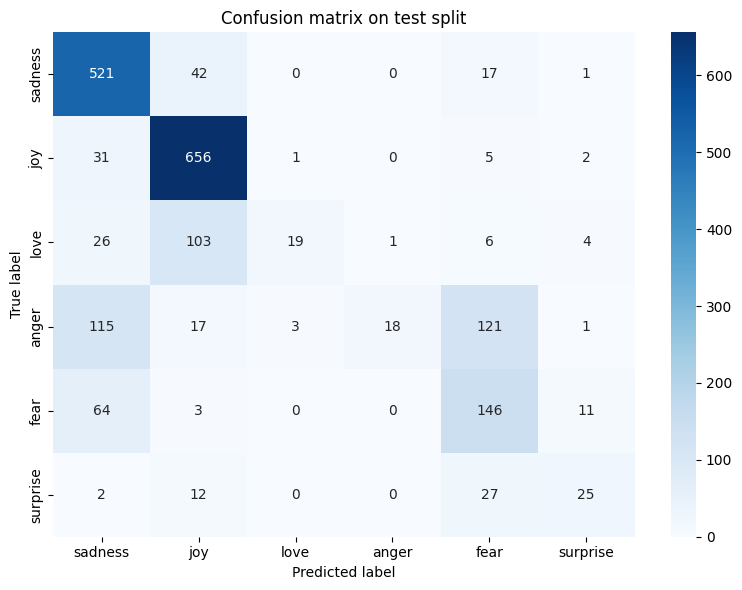

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,joy,0.6929
1,im updating my blog because i feel shitty,sadness,sadness,0.5965
2,i never make her separate from me because i do...,sadness,sadness,0.5785
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.7325
4,i was feeling a little vain when i did this one,sadness,sadness,0.5966
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.3265
6,i felt anger when at the end of a telephone call,anger,sadness,0.4629
7,i explain why i clung to a relationship with a...,joy,joy,0.3476
8,i like to have the same breathless feeling as ...,joy,joy,0.5964
9,i jest i feel grumpy tired and pre menstrual w...,anger,sadness,0.5822


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,joy,0.6929
6,i felt anger when at the end of a telephone call,anger,sadness,0.4629
9,i jest i feel grumpy tired and pre menstrual w...,anger,sadness,0.5822
12,i pay attention it deepens into a feeling of b...,fear,sadness,0.3659
14,i find myself in the odd position of feeling s...,love,joy,0.6975
16,i feel a little mellow today,joy,sadness,0.4083
18,i feel just bcoz a fight we get mad to each ot...,anger,sadness,0.4293
26,i am feeling outraged it shows everywhere,anger,fear,0.3405
28,i do feel insecure sometimes but who doesnt,fear,sadness,0.3800
29,i highly recommend visiting on a wednesday if ...,anger,sadness,0.2815


In [15]:
cm = confusion_matrix(test_labels, test_preds, labels=list(range(len(label_names))))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix on test split")
plt.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=160, bbox_inches="tight")
plt.show()

sample_df = pd.DataFrame(
    {
        "text": ds["test"]["text"],
        "true_label": [id2label[i] for i in test_labels],
        "pred_label": [id2label[i] for i in test_preds],
        "confidence": np.round(test_conf, 4),
    }
)
sample_df.to_csv(SAMPLE_PREDICTIONS_PATH, index=False)

display(sample_df.head(10))

errors_df = sample_df[sample_df["true_label"] != sample_df["pred_label"]].copy()
display(errors_df.head(10))

## 6. Короткий анализ ошибок


In [16]:
recalls = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
best_class = label_names[int(np.argmax(recalls))]
worst_class = label_names[int(np.argmin(recalls))]

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
confused_pair_idx = np.unravel_index(np.argmax(cm_off), cm_off.shape)
confused_pair = (label_names[confused_pair_idx[0]], label_names[confused_pair_idx[1]])

print("Best class by recall:", best_class)
print("Worst class by recall:", worst_class)
print("Most frequent confusion:", confused_pair, int(cm_off[confused_pair_idx]))


Best class by recall: joy
Worst class by recall: anger
Most frequent confusion: ('anger', 'fear') 121


## 7. Дополнительный график обучения


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
1,NaN,NaN,NaN,1.0,500,1.164472,0.6120,0.343344,1.4129,1415.501,22.648,NaN,NaN,NaN,NaN,NaN
2,1.080541,2.974797,5.000000e-08,2.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,1000,0.965443,0.6755,0.505560,1.4444,1384.618,22.154,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,106.7489,299.769,9.368,4.123820e+12,1.272133
5,NaN,NaN,NaN,2.0,1000,0.965443,0.6755,0.505560,1.2819,1560.174,24.963,NaN,NaN,NaN,NaN,NaN


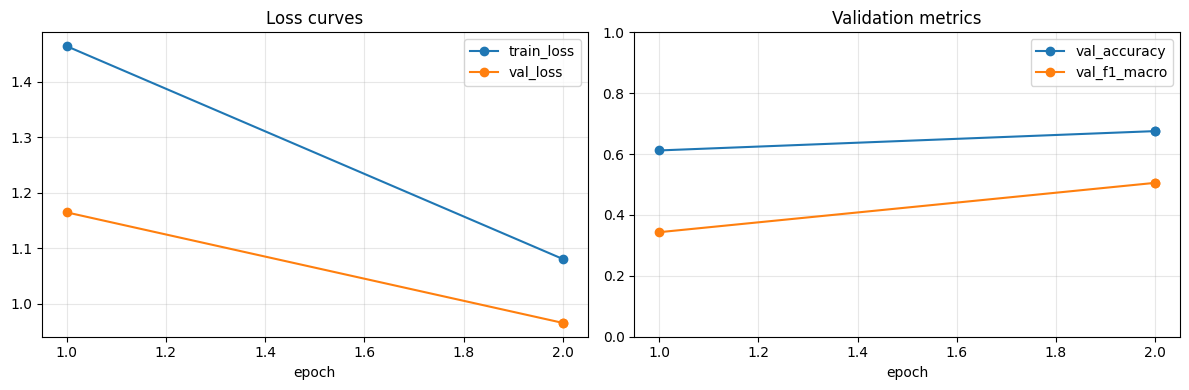

In [17]:
log_history = pd.DataFrame(trainer.state.log_history)
display(log_history.tail())

train_curve = log_history.dropna(subset=["loss"])[["epoch", "loss"]].copy()
eval_curve = log_history.dropna(subset=["eval_loss"])[["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_curve["epoch"], train_curve["loss"], marker="o", label="train_loss")
axes[0].plot(eval_curve["epoch"], eval_curve["eval_loss"], marker="o", label="val_loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(eval_curve["epoch"], eval_curve["eval_accuracy"], marker="o", label="val_accuracy")
axes[1].plot(eval_curve["epoch"], eval_curve["eval_f1_macro"], marker="o", label="val_f1_macro")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
fig.savefig(TRAINING_CURVES_PATH, dpi=160, bbox_inches="tight")
plt.show()


In [18]:
summary = {
    "dataset_name": DATASET_NAME,
    "label_names": label_names,
    "train_size": len(ds["train"]),
    "validation_size": len(ds["validation"]),
    "test_size": len(ds["test"]),
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "device": str(DEVICE),
    "seed": SEED,
    "python_version": sys.version.split()[0],
    "datasets_version": __import__("datasets").__version__,
    "transformers_version": __import__("transformers").__version__,
    "torch_version": torch.__version__,
    "validation_metrics": {k: float(v) for k, v in val_metrics.items() if isinstance(v, (int, float))},
    "test_accuracy": float(test_accuracy),
    "test_f1_macro": float(test_f1_macro),
    "best_class_by_recall": best_class,
    "worst_class_by_recall": worst_class,
    "most_frequent_confusion": {
        "true_label": confused_pair[0],
        "pred_label": confused_pair[1],
        "count": int(cm_off[confused_pair_idx]),
    },
    "pretrained_inference_examples": pretrained_rows,
    "sample_prediction_rows": sample_df.head(10).to_dict(orient="records"),
    "error_rows": errors_df.head(5).to_dict(orient="records"),
    "artifacts": {
        "sample_predictions_csv": str(SAMPLE_PREDICTIONS_PATH.name),
        "confusion_matrix_png": str(CONFUSION_MATRIX_PATH.name),
        "training_curves_png": str(TRAINING_CURVES_PATH.name),
    },
}

print(json.dumps(summary, ensure_ascii=False, indent=2)[:1500])


{
  "dataset_name": "emotion",
  "label_names": [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
  ],
  "train_size": 16000,
  "validation_size": 2000,
  "test_size": 2000,
  "model_name": "google/bert_uncased_L-2_H-128_A-2",
  "max_length": 64,
  "train_batch_size": 32,
  "eval_batch_size": 64,
  "num_epochs": 2,
  "learning_rate": 5e-05,
  "weight_decay": 0.01,
  "device": "cpu",
  "seed": 42,
  "python_version": "3.14.0",
  "datasets_version": "4.8.4",
  "transformers_version": "5.5.0",
  "torch_version": "2.10.0+cpu",
  "validation_metrics": {
    "eval_loss": 0.9654428958892822,
    "eval_accuracy": 0.6755,
    "eval_f1_macro": 0.5055596229037534,
    "eval_runtime": 1.2819,
    "eval_samples_per_second": 1560.174,
    "eval_steps_per_second": 24.963,
    "epoch": 2.0
  },
  "test_accuracy": 0.6925,
  "test_f1_macro": 0.49280581024683995,
  "best_class_by_recall": "joy",
  "worst_class_by_recall": "anger",
  "most_frequent_confusion": {
    "true_lab